# NumMod, Skoltech, Term 3, 2023

## Problem Set 1

### Problem 1 (30pt)

Consider the following function
$$f(x) = \sqrt{x}$$
on the interval $x \in [0, 1]$.

* (a) Interpolate the function with piecewise constant and piecewise linear interpolation on a uniform mesh. Find, approximately, the maximal error of interpolation (you can sample the function at several points inside each interpolation interval), as a function of the interval length.
* (b) Find the integral of $f(x)$ on the interval $[0,1]$ by using the midpoint rule, the trapeziodal rule and Simpson's method. Compute the error and compare the error between the three methods. What is the order of convergence of each of these three methods?

### Modeling a Cantilever Beam

Consider a beam fixed at one end (called a [cantilever](http://en.wikipedia.org/wiki/Cantilever) beam) as shown here:
<img src='fig/beam_basic.png'>

<a id="eq"></a>
Its deflection from the equilibrium position is described by the deflection $u = u(x)$ which satisfies the boundary-value problem for the [Euler-Bernoulli equation](http://en.wikipedia.org/wiki/Euler%E2%80%93Bernoulli_beam_theory)
$$ (EIu'')'' = 0 \qquad \qquad \quad $$
$$u(0)=0 \qquad u'(0)=0 \qquad \qquad (1)$$
$$u''(L)=0 \qquad (EIu'')'(L)=P \qquad \qquad \quad $$

where $P$ is the force applied to the beam’s end, $E$ is the (constant) elastic modulus (a material’s property) and $I$ is the second moment of the area of the cross-section. If the cross-section is a rectangle with height $~H = H(x)$ and the width is $W$ then  $~I = I(x) = WH(x)^3/12$ (see more details in Wikipedia under the link above).

To solve the problem we rewrite it as a system
$$ u'' = v $$
$$ (EIv)'' =0 $$
$$u(0)=0 \qquad u'(0)=0 \qquad \qquad (2)$$
$$v(L)=0 \qquad (EIv)'(L)=P \qquad \qquad \quad $$

$$\require{cancel}$$

### Problem 2 (40pt)

Assume that $~I = I(x)$ is constant.

* **(10pt)** Write a code that implements this finite difference problem solving the system (2)


* **(10pt)** For the given parameters $E = 2.5\, \text{GPa}$, $H = 7\,\text{mm}$, $W = 3\,\text{mm}$, $L = 25\, \text{cm}$, $P = m \cdot g, m = 200\,\text{g}, g = 9810\,\text{mm}/\text{s}^2$, $h = L/20$ use your code to compute the solution $u_h$. What is the computed deflection of the right end, $u_h(L)$?

<!-- NOT NEEDED: 
*  (Optional.) Upload the values $u(0), u(h), ... , u(L)$ at SI units (in meters in this case) to Canvas as a text file named *Your_Name.txt* with numbers separated by a newline. The first one who does it correctly will get a non-material bonus. (The details on uploading to Canvas may be changed later.)
-->


* **(10pt)** Find the solution $u$ in the analytic form. Compare $~u(L)~$ with $~u_h(L)~$ for $~h = L/25,L/50,L/100~$. As you decrease $~h~$ by a factor or 2, by what factor does the difference $~|u_h(L) − u(L)|~$ decrease?


* **(10pt)** Compute $~\sigma _{\min}(A_h)~$ and $~\sigma _{\max}(A_h)~$ for $~h = L/25, L/50, L/100$, where $A_h$ is the matrix of the discretized linear system. As you decrease $~h~$ by a factor or 2, by what factor does $\operatorname{cond}(A_h)$ increase? (Alternatively, compute $\lambda _{\min}(A_h)$ and $\lambda _{\max}(A_h)$ and comment on how $\lambda _{\max}(A_h)$/$\lambda _{\min}(A_h)$ increases.)

* **(0pt / bonus question)** 
Can you find, approximately, for what $h$ your code computes the value $~|u_h(L)−u(L)|~$ most accurately? Explain why your code’s answers are worse if $~h~$ is less than this value and if $~h~$ is larger than this value.

### Problem 3 (30pt)

Let all parameters be the same as in Problem 2 except for $H(x) = (3 − 2x/L)(2 + \cos(18πx/L)) · 6\, \text{mm}$.

* **(10pt)** Formulate the corresponding finite difference problem.


* **(10pt)** Write the corresponding code.


* **(10pt)** Assuming that the beam fractures at the point where the modulus of the quantity $\sigma(x) = u''(x)H(x)$ is largest, find the point where the beam should fracture. Give details on how you compute it (e.g., what value of h you used).

***

### Problem 1

Consider the following function
$$f(x) = \sqrt{x}$$
on the interval $x \in [0, 1]$.

* (a) Interpolate the function with piecewise constant and piecewise linear interpolation on a uniform mesh. Find, approximately, the maximal error of interpolation (you can sample the function at several points inside each interpolation interval), as a function of the interval length.

C:\Users\User\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\User\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


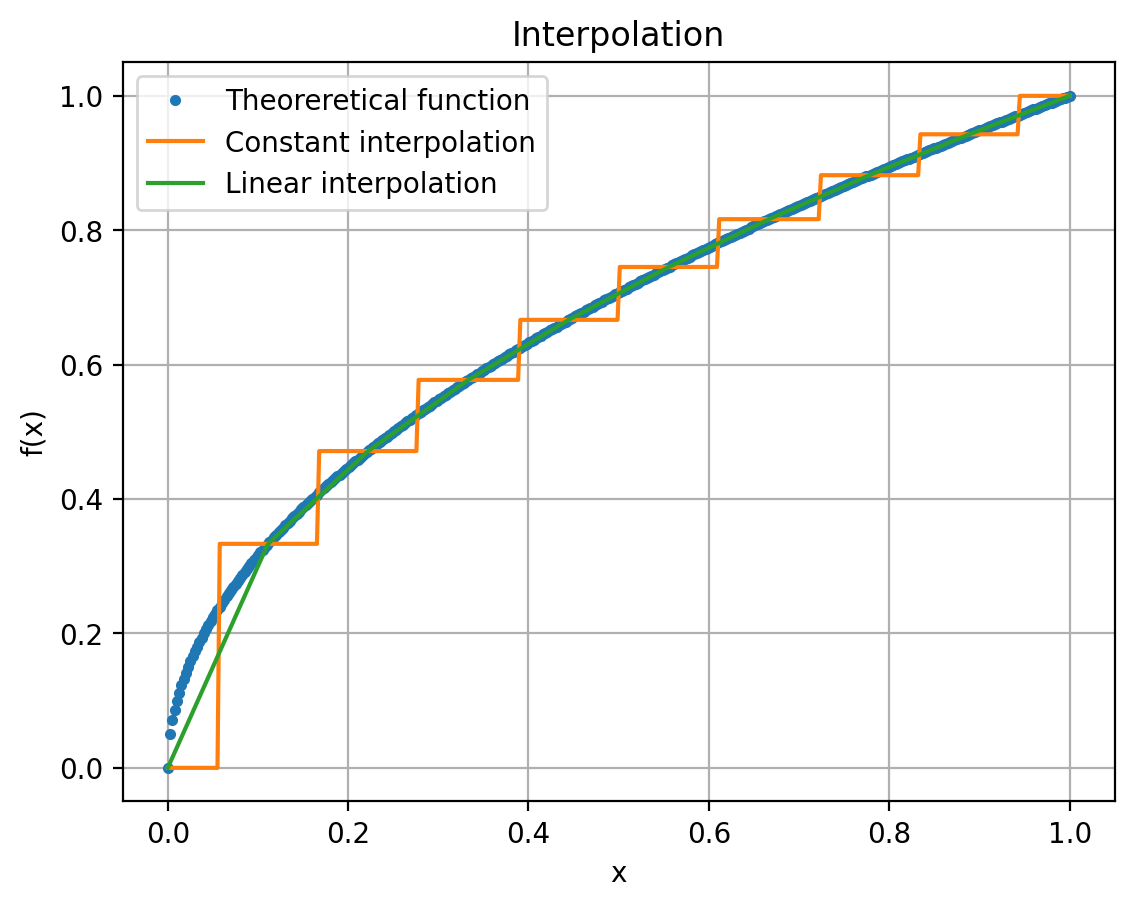

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def f_true(x):
    return np.sqrt(x)

def uniform_grid(n):
    return np.linspace(0,1,n)



#piecewise constant interpolation

def f_pwc(x, x_grid):
    x_nearest_ind = [np.abs(x_grid - i).argmin() for i in x]
    x_nearest = x_grid[x_nearest_ind]
    return f_true(x_nearest)

def constant(x, x_dense):
    n_dense = x_dense.shape[0]
    array = np.empty(n_dense)
    array = f_pwc(x_dense, x_grid)
    return array



# piecewise linear interpolation

def f_pwlin(x, x_grid):
    x_nearest_ind = np.abs(x_grid - x).argmin()
    x_nearest = x_grid[x_nearest_ind]
    
    if x_nearest == x:
        return f_true(x_nearest)
    elif x_nearest > x:
        x_nearest_left = x_grid[x_nearest_ind - 1]
        x_nearest_right = x_grid[x_nearest_ind]
    else:
        x_nearest_left = x_grid[x_nearest_ind]
        x_nearest_right = x_grid[x_nearest_ind + 1]
        
    weight = (x - x_nearest_left) / (x_nearest_right - x_nearest_left)
    return f_true(x_nearest_left) + (f_true(x_nearest_right) - f_true(x_nearest_left)) * weight

def linear(x, x_dense):
    n_dense = x_dense.shape[0]
    array = np.empty(n_dense)
    for i in range(n_dense):
        array[i] = f_pwlin(x_dense[i], x_grid)
    return array


# interpolation points
x_dense_grid = uniform_grid(400)

# uniform mesh with known function value
x_grid = uniform_grid(10)

f_const = constant(x_grid, x_dense_grid)
f_lin = linear(x_grid, x_dense_grid)
f_t = f_true(x_dense_grid)

plt.figure(dpi = 200)
plt.plot(x_dense_grid,f_t, '.', label = 'Theoreretical function')
plt.plot(x_dense_grid,f_const, label = 'Constant interpolation')
plt.plot(x_dense_grid,f_lin, label = 'Linear interpolation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Interpolation')
plt.legend()
plt.grid()

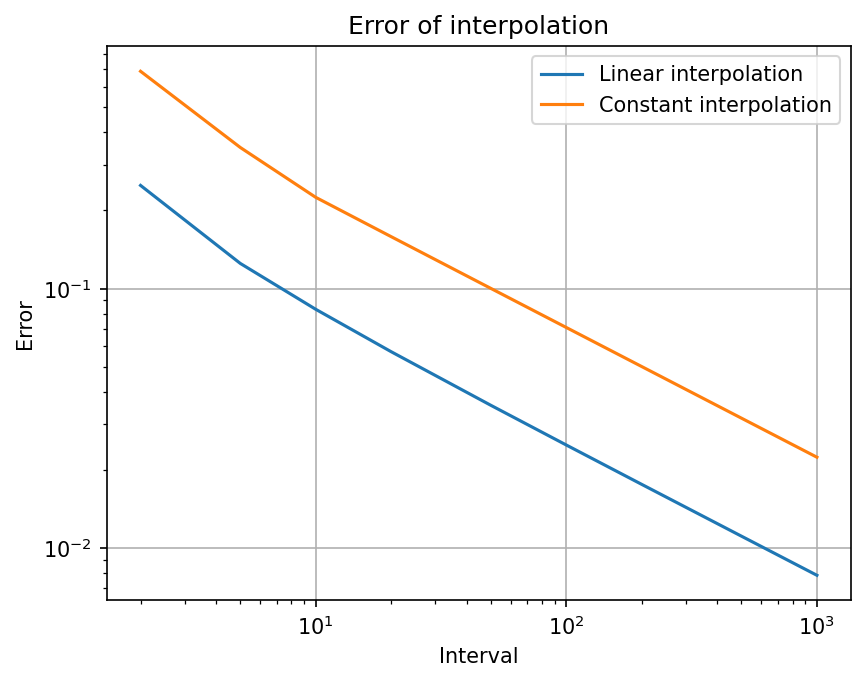

In [3]:
def error(a, b):
    return np.abs(a - b)

# x_dense_grid = uniform_grid(500)

errors_lin = np.array([])
errors_con = np.array([])

# intervals = np.linspace(100,1000,10).astype(int)
intervals = [2,5,10,20,50,100,200,500,1000]
for interval in intervals:
    x_grid = uniform_grid(interval)
    x_dense_grid = uniform_grid(10*interval)
    f_const = constant(x_grid, x_dense_grid)
    f_lin = linear(x_grid, x_dense_grid)
    f_t = f_true(x_dense_grid)
    
    error_lin = (error(f_lin, f_t)).max()
    error_con = (error(f_const, f_t)).max()
    
    errors_lin = np.append(errors_lin,error_lin)
    errors_con = np.append(errors_con,error_con)
    
    
plt.figure(dpi = 150)
    
plt.plot(intervals, errors_lin, label = 'Linear interpolation')
plt.plot(intervals, errors_con, label = 'Constant interpolation')

plt.title('Error of interpolation')
plt.xlabel('Interval')
plt.ylabel('Error')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()

* (b) Find the integral of $f(x)$ on the interval $[0,1]$ by using the midpoint rule, the trapeziodal rule and Simpson's method. Compute the error and compare the error between the three methods. What is the order of convergence of each of these three methods?

Midpoint Rule Integral: 0.6666876731570722
Trapezoidal Rule Integral: 0.6665942094533094
Simpson's Method Integral: 0.66663796357003
Error of Midpoint Rule Integral: 2.1006490405595102e-05
Error of Trapezoidal Rule Integral: 7.245721335724653e-05
Error of Simpson's Method Integral: 2.8703096636606418e-05
The rate of convergence Midpoint rule: 1.5064850783925874
The rate of convergence Trapesoidal rule: 1.5158040084464517
The rate of convergence Simpsons method: 1.5282122516632939


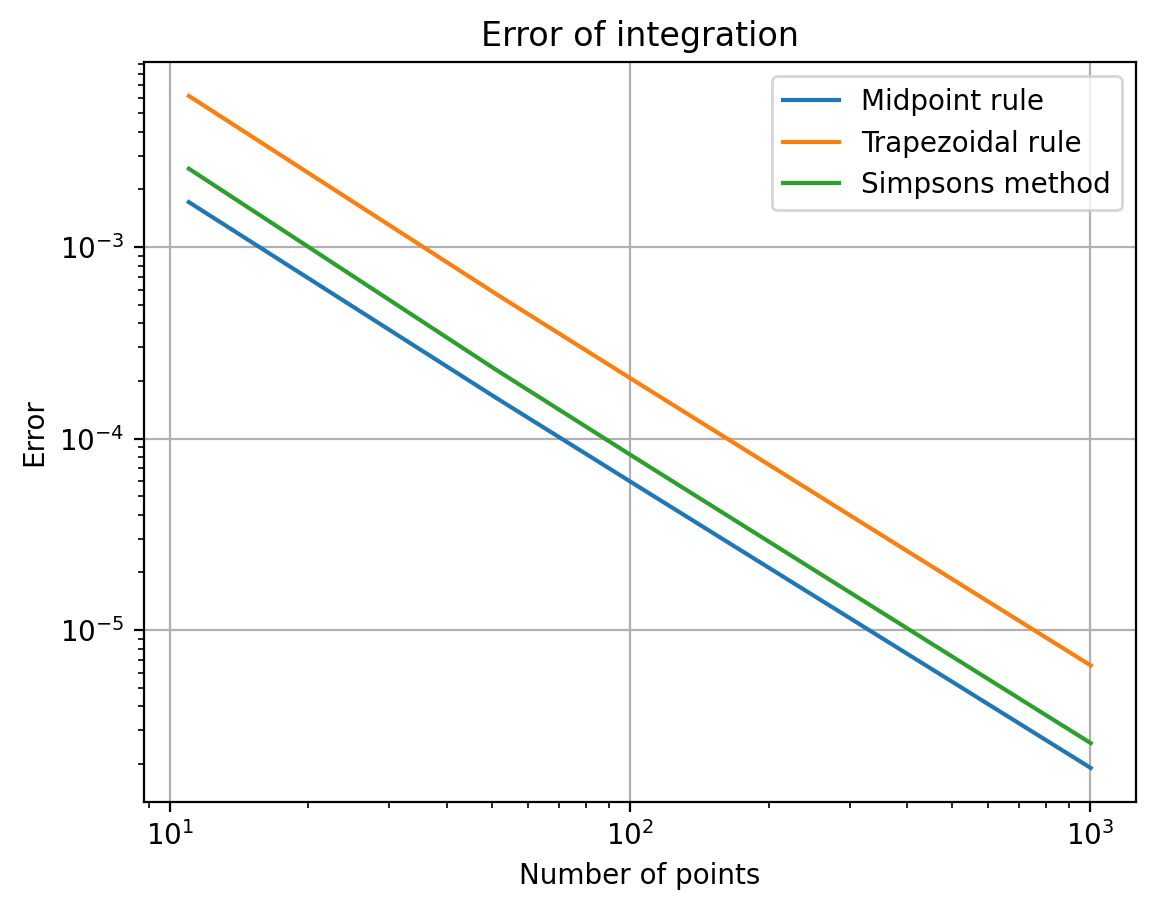

In [4]:
x_grid = uniform_grid(201)

def f_true(x):
    return np.sqrt(x)
#     return np.sin(x)

# midpoint rule
def midpoint(x):

    n = x.shape[0]
    h = 1/(n-1)
    X = x[:-1] + 0.5*h
    func = f_true(X)*h
    integral = np.sum(func)
    return integral

# trapezoidal rule
def trapezoidal(x):
    h = 1/(x.shape[0]-1)
    integral = h*((f_true(x[0]) + f_true(x[-1]))/2 + np.sum(f_true(x[1:-1])))
    return integral

# simpson's method
def simpson(x):
    n = x.shape[0]
    h = 1/(n-1)
    integral = f_true(x[0]) + f_true(x[-1]) + 4*np.sum(f_true([x[i] for i in range(1,n-1,2)])) + 2*np.sum(f_true([x[i] for i in range(2,n-2,2)]))
    integral *= h/3
    return integral

# exact solution
def f(x):
    return 2/3*x**(3/2)
#     return np.cos(0) - np.cos(x)

def error(a):
    return np.abs(a - f(1))

mp = midpoint(x_grid)
tr = trapezoidal(x_grid)
sm = simpson(x_grid)

print("Midpoint Rule Integral:", mp)
print("Trapezoidal Rule Integral:", tr)
print("Simpson's Method Integral:", sm)

print("Error of Midpoint Rule Integral:", error(mp))
print("Error of Trapezoidal Rule Integral:", error(tr))
print("Error of Simpson's Method Integral:", error(sm))

errors_mp = np.array([])
errors_tr = np.array([])
errors_sm = np.array([])

ns = [11,51,101,501,1001]

# the order of convergence
for n in ns:
    
    x_grid = uniform_grid(n)
    
    mp = midpoint(x_grid)
    tr = trapezoidal(x_grid)
    sm = simpson(x_grid)
    
    errors_mp = np.append(errors_mp, error(mp))
    errors_tr = np.append(errors_tr, error(tr))
    errors_sm = np.append(errors_sm, error(sm))
    
conv_mp, _ = np.polyfit(np.log(ns),np.log(errors_mp), 1)
conv_tr, _ = np.polyfit(np.log(ns),np.log(errors_tr), 1)
conv_sm, _ = np.polyfit(np.log(ns),np.log(errors_sm), 1)
    
plt.figure(dpi = 200)
plt.plot(ns,errors_mp, label = 'Midpoint rule')
plt.plot(ns,errors_tr, label = 'Trapezoidal rule')
plt.plot(ns,errors_sm, label = 'Simpsons method')
plt.title('Error of integration')
plt.xlabel('Number of points')
plt.ylabel('Error')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.legend()



print('The rate of convergence Midpoint rule:', np.abs(conv_mp))
print('The rate of convergence Trapesoidal rule:', np.abs(conv_tr))
print('The rate of convergence Simpsons method:', np.abs(conv_sm))

### Problem 2 (40pt)

Assume that $~I = I(x)$ is constant.

* **(10pt)** Write a code that implements this finite difference problem solving the system (2)

In [5]:
from pyamg.gallery import stencil_grid
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

def make_matrix(n, L):
    h = L/(n-1)
    grid = (n,)        
    stencil = [1,-4,6,-4,1] 
    A = stencil_grid(stencil, grid, dtype=float, format='csr')
    A = A.toarray()

    # u'(0)=0
    r1 = np.zeros(n+1)
    r1[0:3] = -h**3/2, 0, h**3/2
    c1 = np.zeros((n,1))
    c1[:2,0] = -4, 1
    A = np.hstack((c1,A))
    A = np.vstack([r1, A])

    # u(0)=0
    A = np.delete(A, (1), axis=0)
    A = np.delete(A, (1), axis=1)
    
    # u''(L)=0
    c_n1 = np.zeros((n,1))
    c_n1[n-2:, 0] = 1, -4
    r_n1 = np.zeros(n+1)
    r_n1[n-2:] = h**2, -2*h**2, h**2
    A = np.hstack((A, c_n1))
    A = np.vstack([A, r_n1])

    # (EIu'')'(L)=P
    c_n2 = np.zeros((n+1,1))
    c_n2[n-1,0] = 1
    r_n2 = np.zeros(n+2)
    r_n2[n-3:] = -h/2, h, 0, -h, h/2
    A = np.hstack((A, c_n2))
    A = np.vstack([A, r_n2])
    
    return A/h**4

* **(10pt)** For the given parameters $E = 2.5\, \text{GPa}$, $H = 7\,\text{mm}$, $W = 3\,\text{mm}$, $L = 25\, \text{cm}$, $P = m \cdot g, m = 200\,\text{g}, g = 9810\,\text{mm}/\text{s}^2$, $h = L/20$ use your code to compute the solution $u_h$. What is the computed deflection of the right end, $u_h(L)$?

In [6]:
P = 0.2*9.81
E = 2.5*10**9
W = 3*10**(-3)
L = 0.25
H = 7*10**(-3)
I = W*H**(3)/12
n = 21

A = make_matrix(n,L)

f = np.zeros((n+2,1))
f[-1] = P/E/I

u = np.linalg.solve(A, f).T[0]
u = np.append(0,u[1:-2])

print('Deflection of the right end is', u[-1], 'm')

Deflection of the right end is -0.047727223032295575 m


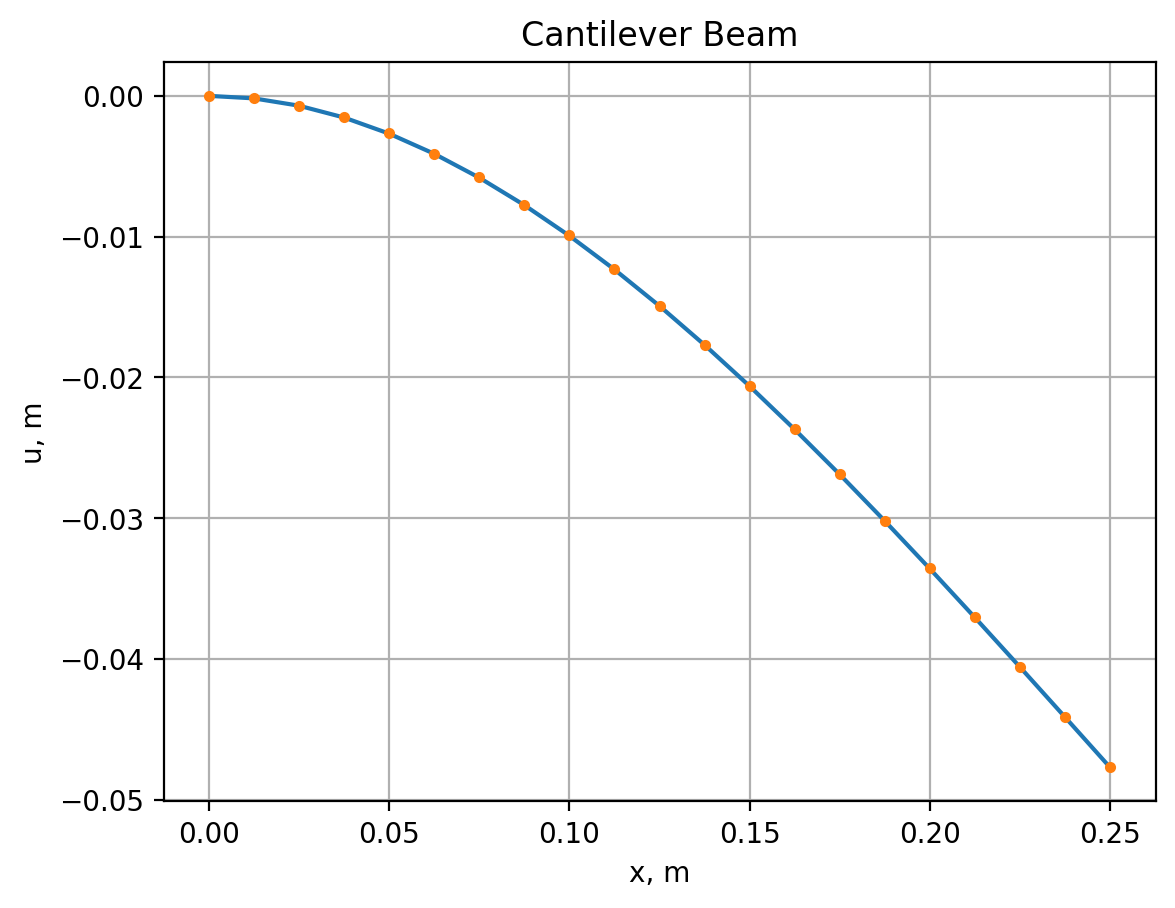

In [8]:
def solution(x):
    return P/6/E/I*x**3 - P*L/2/E/I*x**2

x = np.linspace(0,L, n)
plt.figure(dpi = 200)
plt.plot(x,u, label = 'Numerical solution')
plt.plot(x,solution(x), '.', label = 'Theoretical solution')
plt.xlabel('x, m')
plt.ylabel('u, m')
plt.title('Cantilever Beam')
plt.grid()

* **(10pt)** Find the solution $u$ in the analytic form. Compare $~u(L)~$ with $~u_h(L)~$ for $~h = L/25,L/50,L/100~$. As you decrease $~h~$ by a factor or 2, by what factor does the difference $~|u_h(L) − u(L)|~$ decrease?

The difference |uh(L) - u(L)| decrease by a factor 2.0431102673762536


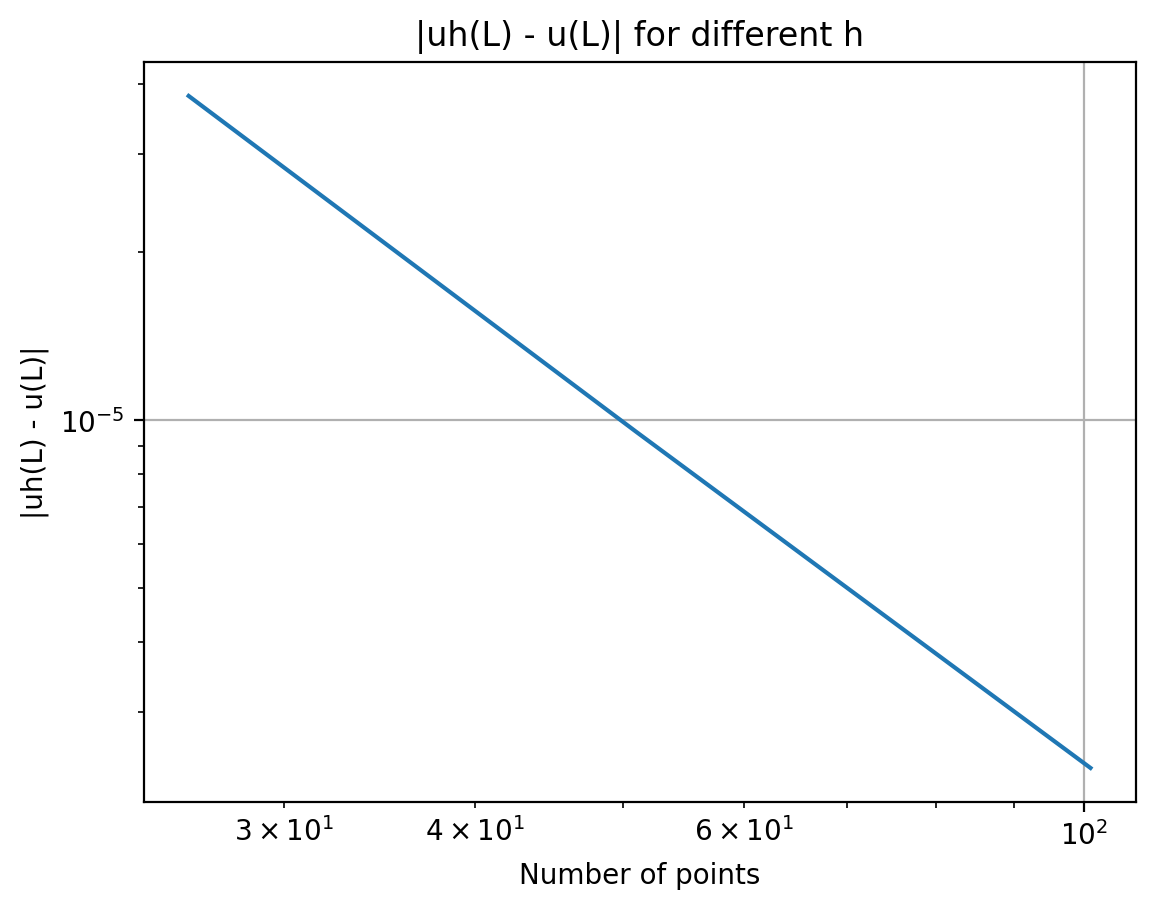

In [9]:
def solution(x):
    return P/6/E/I*x**3 - P*L/2/E/I*x**2

errors = np.array([])

ns = [26,51,101]
for n in ns:
    A = make_matrix(n,L)
    
    f = np.zeros((n+2,1))
    f[-1] = P/E/I

    u = np.linalg.solve(A, f).T[0]
    u = np.append(0,u[1:-2])
    
    u_theor = solution(x)
    
    errors = np.append(errors, np.abs(u[-1] - u_theor[-1]))
    
plt.figure(dpi = 200)
plt.plot(ns, errors)
plt.xscale('log')
plt.yscale('log')
plt.title('|uh(L) - u(L)| for different h')
plt.ylabel('|uh(L) - u(L)|')
plt.xlabel('Number of points')
plt.grid()
    
rate, _ = np.polyfit(np.log(ns),np.log(errors), 1)
print('The difference |uh(L) - u(L)| decrease by a factor', np.abs(rate))

* **(10pt)** Compute $~\sigma _{\min}(A_h)~$ and $~\sigma _{\max}(A_h)~$ for $~h = L/25, L/50, L/100$, where $A_h$ is the matrix of the discretized linear system. As you decrease $~h~$ by a factor or 2, by what factor does $\operatorname{cond}(A_h)$ increase? (Alternatively, compute $\lambda _{\min}(A_h)$ and $\lambda _{\max}(A_h)$ and comment on how $\lambda _{\max}(A_h)$/$\lambda _{\min}(A_h)$ increases.)

Condition number of A increases exponentialy with the rate 4.523354488301999


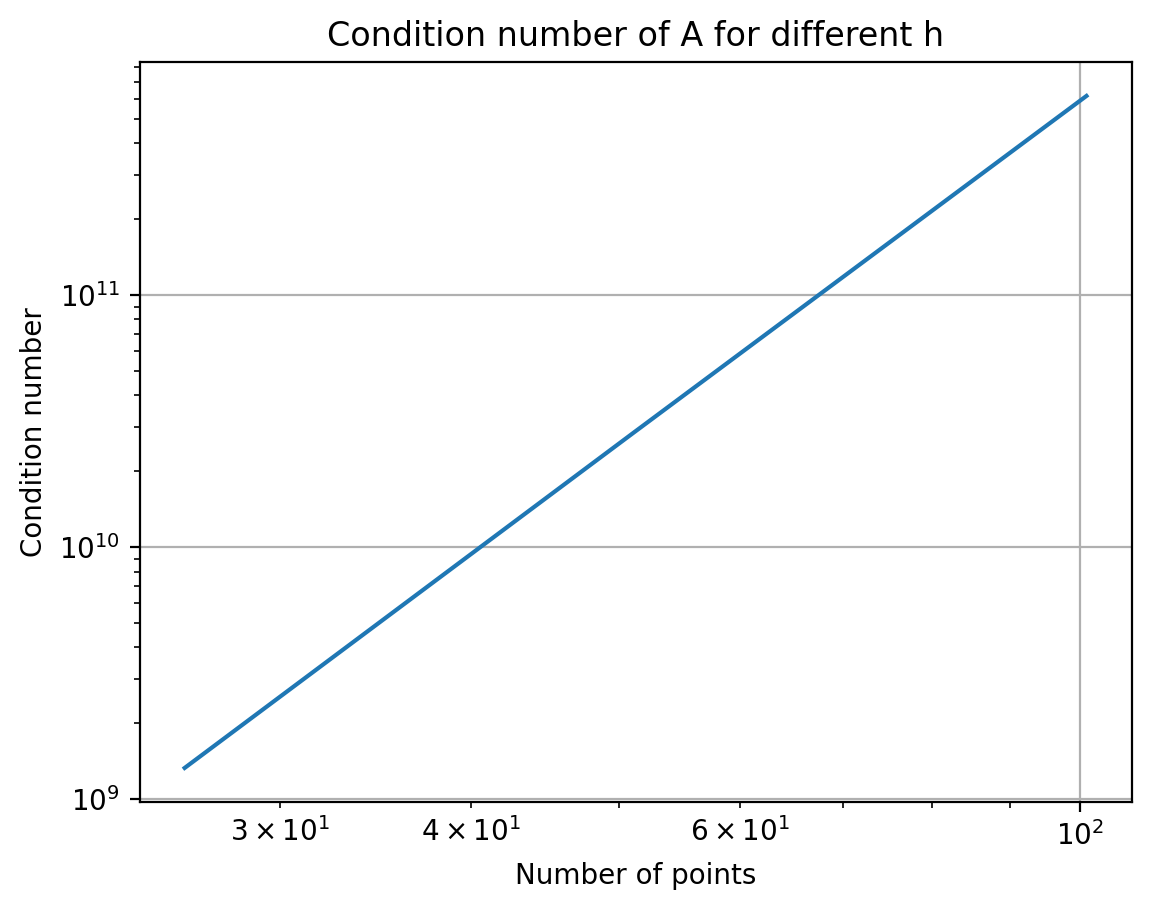

In [10]:
cond = np.array([])

ns = [26,51,101]
for n in ns:
    A = make_matrix(n,L)
    
    _, S, _ = np.linalg.svd(A)
    cond = np.append(cond, np.abs(S[0]/S[-1]))
    
plt.figure(dpi = 200)
plt.plot(ns, cond)
plt.xscale('log')
plt.yscale('log')
plt.title('Condition number of A for different h')
plt.ylabel('Condition number')
plt.xlabel('Number of points')
plt.grid()

rate, _ = np.polyfit(np.log(ns),np.log(cond), 1)

print('Condition number of A increases exponentialy with the rate', rate)

### Problem 3 (30pt)

Let all parameters be the same as in Problem 2 except for $H(x) = (3 − 2x/L)(2 + \cos(18πx/L)) · 6\, \text{mm}$.

* **(10pt)** Formulate the corresponding finite difference problem.



Let's discretize the equation this way:
$$
D_{m} K(x+h/2) D \ \vec{u(ih)} = 0 
$$
where 
* $D$    is a forward-difference operator
$$
Du(x) = \frac{u(x+ 2h) - 2u(x+h) + u(x)}{h^2}
$$
* $D_m$   is a backward-difference operator
$$
D_m u(x) = \frac{u(x- 2h) - 2u(x-h) + u(x)}{h^2}
$$
* $K = E * I(x)$  

Boundary conditions:

$$
u(0) = 0; \quad D_0 u(0) = \frac{u(h)-u(-h)}{2h} = 0; 
$$
$$
D_0 [u''(L)EI(L)] = P;\quad u''(L) = \frac{u(L-h) - 2u(L) + u(L+h)}{h^2} = 0,
$$

where $D_0$ is central-difference operator.

* **(10pt)** Write the corresponding code.

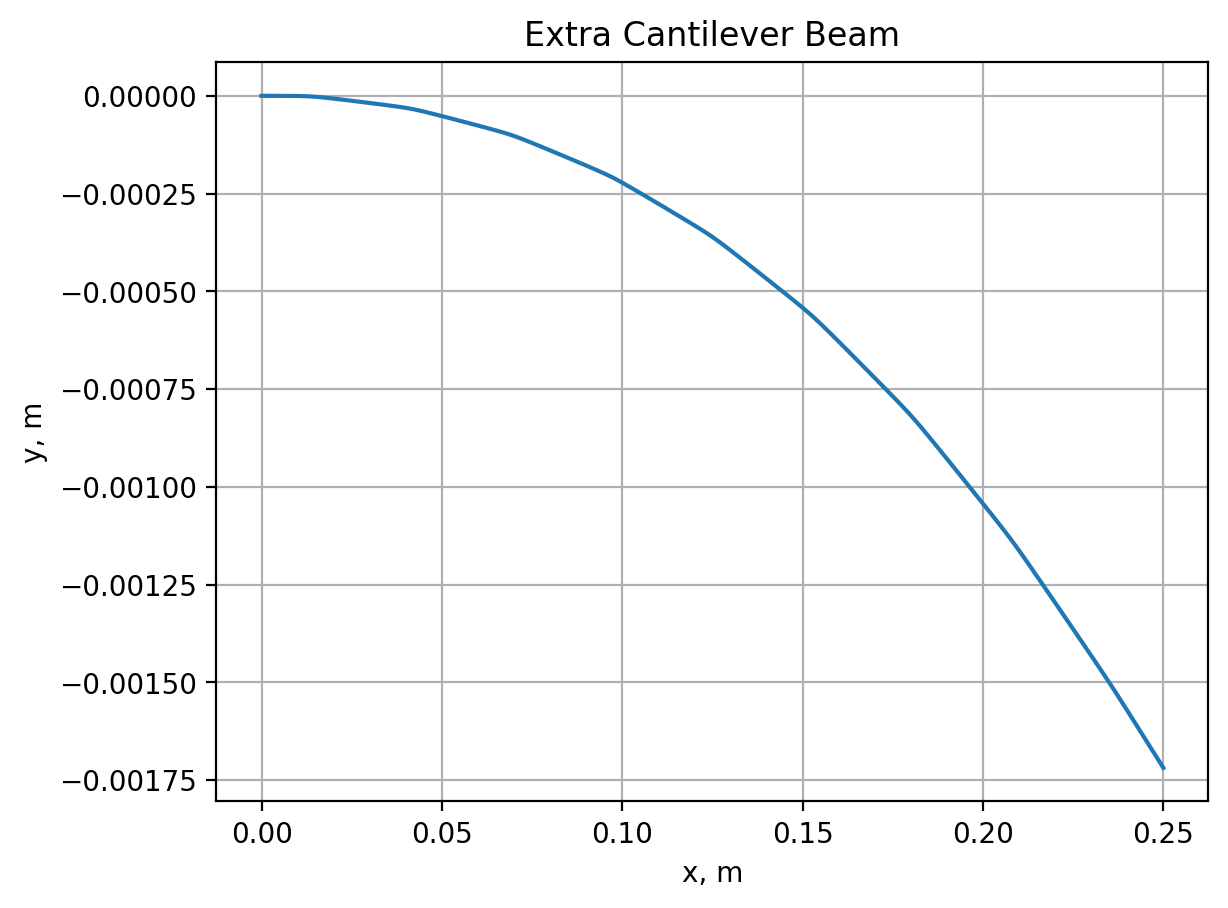

In [11]:
def H(x):
    return 6*(3-2*x/L)*(2+np.cos(18*np.pi*x/L))*10**(-3)

def I(x):
    return W/12*H(x)**3

def K(x):
    return E*I(x)

def D(n):
    stencil = [1,-2,1]  
    grid = (n+3,)       
    A = stencil_grid(stencil, grid, dtype=float, format='csr')
    A = A.toarray()
    return A[1:-1]

def Dk(n):
    return np.diag(K(np.linspace(0, L+h, n+1)))

def Dm(n):
    stencil = [1,-2,1]  
    grid = (n+1,)        
    A = stencil_grid(stencil, grid, dtype=float, format='csr')
    A = A.toarray()
    return A[1:-1]

def make_matrix(n, L):
    h = L/(n-1)
    A = Dm(n) @ Dk(n) @ D(n) / h**4
    
    # u(0) = 0
    r1 = np.zeros(A.shape[1])
    r1[1] = 1
    A = np.vstack([r1, A])

    # u'(0) = 0
    r2 = np.zeros(A.shape[1])
    r2[:3] = -1/2/h, 0, 1/2/h
    A = np.vstack([r2, A])

    # u''(L) = 0
    r3 = np.zeros(A.shape[1])
    r3[-4:-1] = 1/h**2, -2/h**2, 1/h**2
    A = np.vstack([A, r3])

    # (EIu'')'(L)=P
    r4 = np.zeros(A.shape[1])
    I1 = I(L-h)
    I2 = I(L+h)
    r4[-5:] = -I1, 2*I1, -I1 + I2, -2*I2, I2
    r4 = r4*E/2/h**3
    A = np.vstack([A, r4])
    return A

n = 101
h = L/(n-1)

A = make_matrix(n, L)
f = np.zeros(n+3)
f[-1] = P

u = np.linalg.solve(A, f)
x = np.linspace(0,L,n)

plt.figure(dpi = 200)
plt.title('Extra Cantilever Beam')
plt.xlabel('x, m')
plt.ylabel('y, m')
plt.plot(x,u[1:-2])
plt.grid()


* **(10pt)** Assuming that the beam fractures at the point where the modulus of the quantity $\sigma(x) = u''(x)H(x)$ is largest, find the point where the beam should fracture. Give details on how you compute it (e.g., what value of h you used).

As you can see, the position of maximal modulus of sigma doesn't depend on h (if h is large relatively to mashine precision) and is equal to  0.125


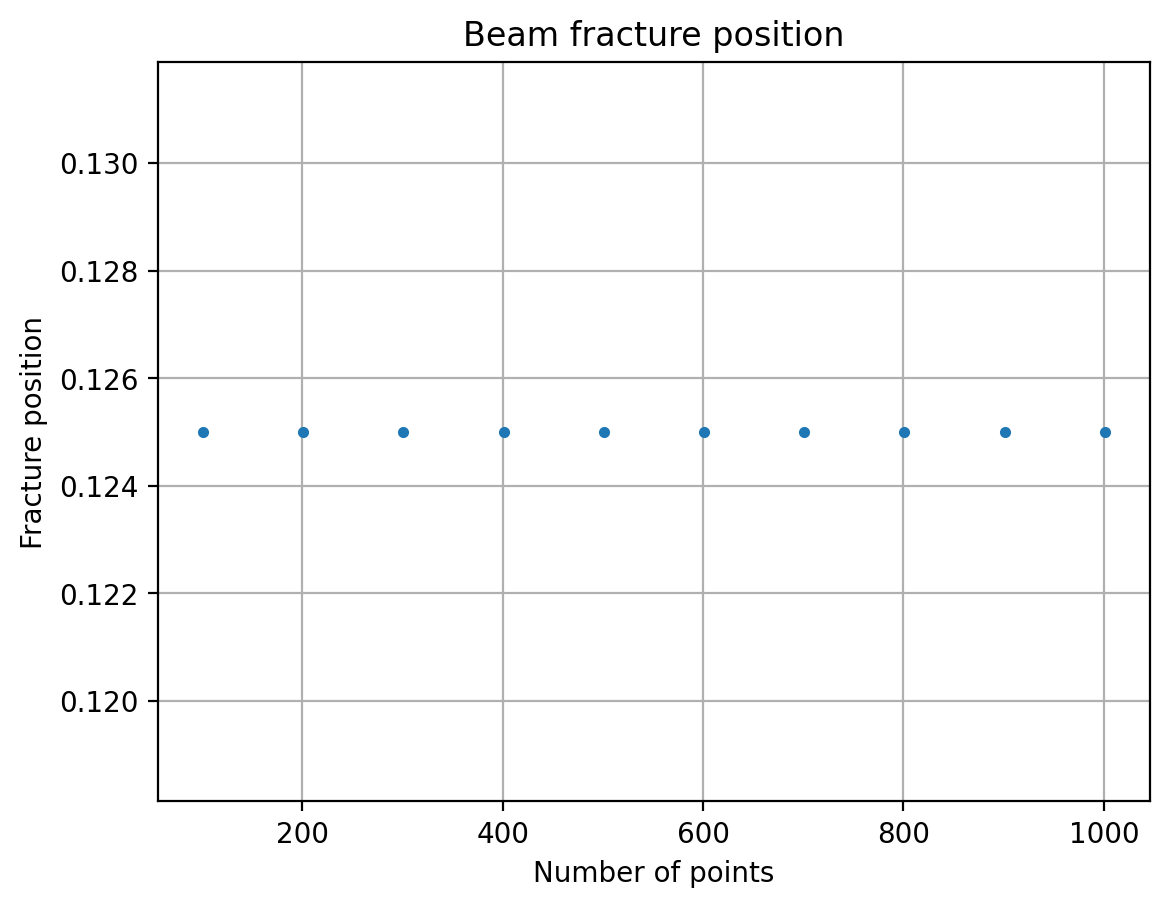

In [20]:
def u2(x):
    return (u[2:-1] -2*u[1:-2] + u[:-3])/h**2

def sigma(x):
    return u2(x)*H(x)

sigmas = np.array([])
ns = np.linspace(100,1000,10).astype(int) + 1
for n in ns:
    h = L/(n-1)

    A = make_matrix(n, L)
    f = np.zeros(n+3)
    f[-1] = P

    u = np.linalg.solve(A, f)
    x = np.linspace(0,L,n)
    
    sigmas = np.append(sigmas, np.argmax(np.abs(sigma(x)))*h)

plt.figure(dpi = 200)
plt.title('Beam fracture position')
plt.xlabel('Number of points')
plt.ylabel('Fracture position')
plt.plot(ns, sigmas, '.')
plt.grid()

print("As you can see, the position of maximal modulus of sigma doesn't depend on h (if h is large relatively to mashine precision) and is equal to ", sigmas.mean())